  + mult_fmm_7mpi_1.out
  + mult_fmm_7mpi_2.out
  + mult_fmm_7mpi_3.out
  + mult_fmm_7mpi_4.out
  + mult_fmm_7mpi_5.out
  + mult_fmm_7mpi_6.out
  + mult_fmm_7mpi_7.out
  + mult_fmm_7mpi_8.out
  + mult_fmm_7mpi_9.out
  + mult_fmm_7mpi_10.out
  + mult_fmm_7mpi_11.out
  + mult_fmm_7mpi_12.out
  + mult_fmm_7mpi_13.out
  + mult_fmm_7mpi_14.out
  + mult_fmm_7mpi_15.out
  + mult_fmm_7mpi_16.out
 → Written mult_fmm_7.out
  + mult_fmm_6mpi_1.out
  + mult_fmm_6mpi_2.out
  + mult_fmm_6mpi_3.out
  + mult_fmm_6mpi_4.out
  + mult_fmm_6mpi_5.out
  + mult_fmm_6mpi_6.out
  + mult_fmm_6mpi_7.out
  + mult_fmm_6mpi_8.out
  + mult_fmm_6mpi_9.out
  + mult_fmm_6mpi_10.out
  + mult_fmm_6mpi_11.out
  + mult_fmm_6mpi_12.out
  + mult_fmm_6mpi_13.out
  + mult_fmm_6mpi_14.out
  + mult_fmm_6mpi_15.out
  + mult_fmm_6mpi_16.out
 → Written mult_fmm_6.out
  + mult_fmm_5mpi_1.out
  + mult_fmm_5mpi_2.out
  + mult_fmm_5mpi_3.out
  + mult_fmm_5mpi_4.out
  + mult_fmm_5mpi_5.out
  + mult_fmm_5mpi_6.out
  + mult_fmm_5mpi_7.ou

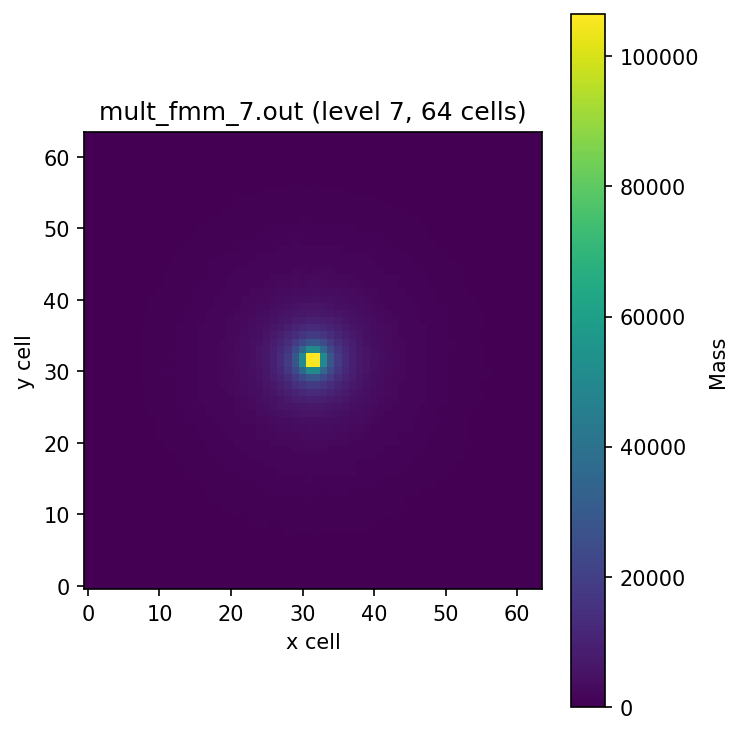


Processing mult_fmm_6.out (level=6, N_cells=32)
Expected particles: 4096.0  Loaded: (32768, 4)
Total mass = 5534195.1325879


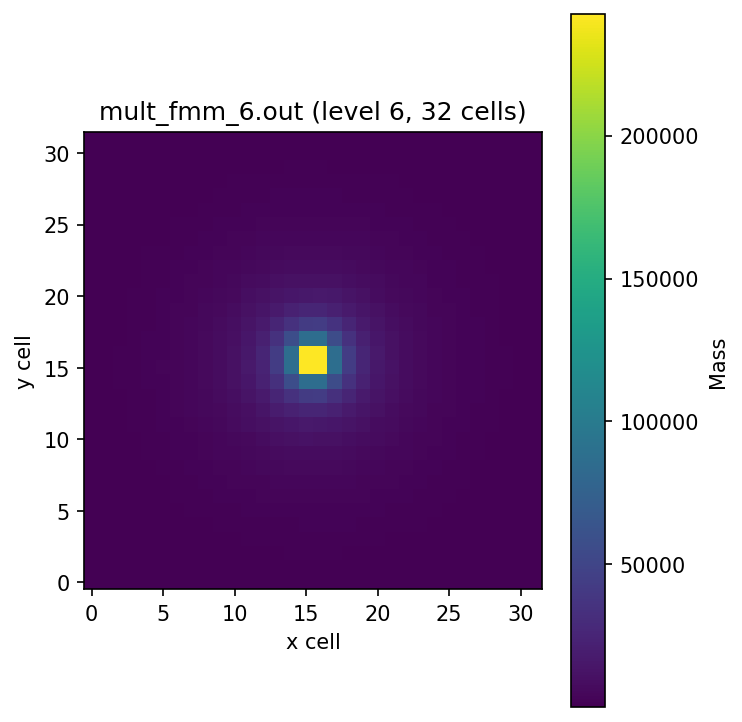


Processing mult_fmm_5.out (level=5, N_cells=16)
Expected particles: 512.0  Loaded: (4096, 4)
Total mass = 5534051.4143199995


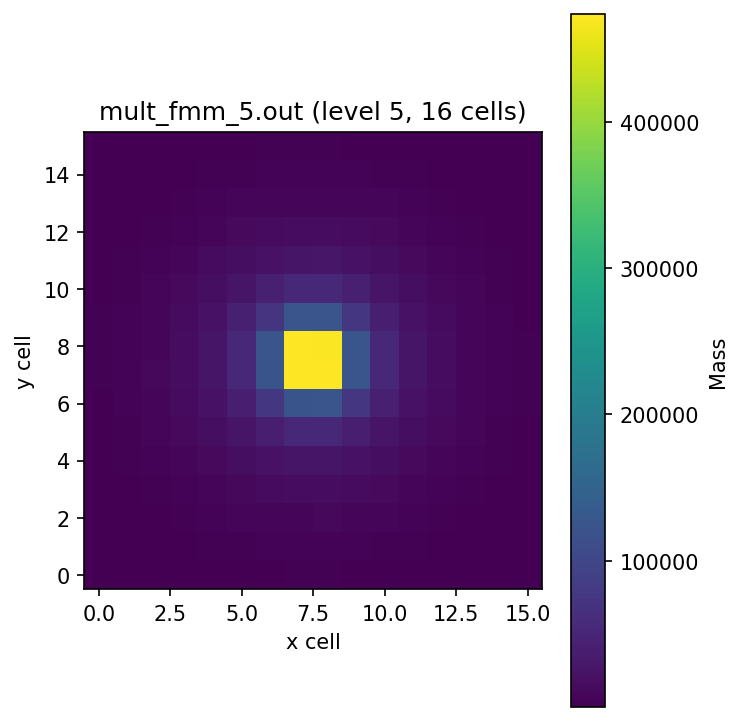


Processing mult_fmm_4.out (level=4, N_cells=8)
Expected particles: 64.0  Loaded: (512, 4)
Total mass = 5534166.528999999


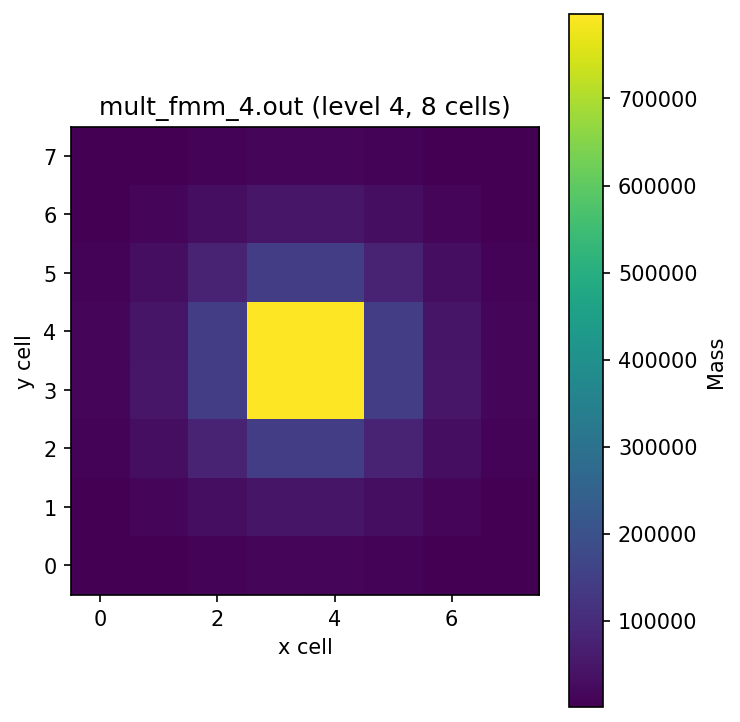


Processing mult_fmm_3.out (level=3, N_cells=4)
Expected particles: 8.0  Loaded: (64, 4)
Total mass = 2765319.0


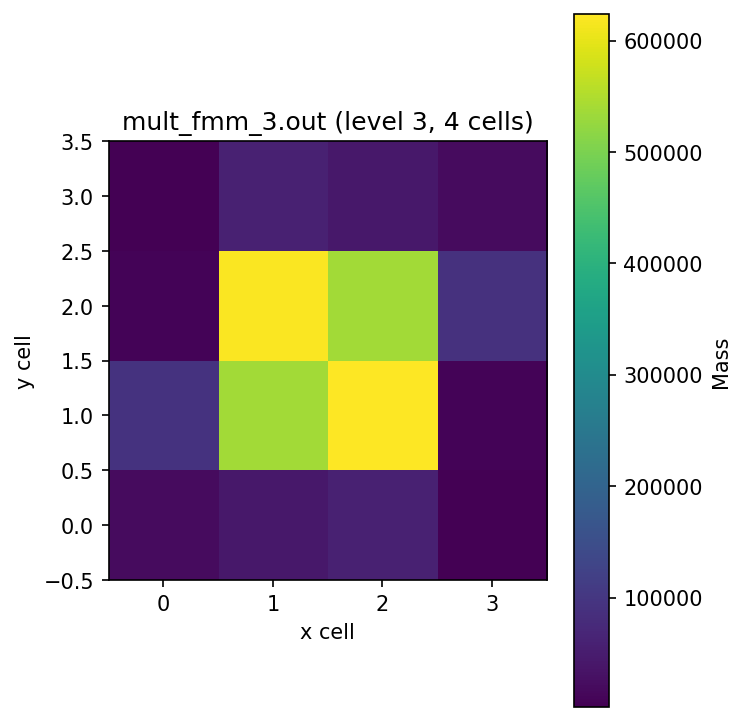

In [8]:
# -*- coding: utf-8 -*-
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 150
plt.rcParams.update({"font.size": 10})

# ---------------------------------------------------
# PARAMETERS
# ---------------------------------------------------
out_dir = "../out"
names = ["x", "y", "z", "m"]  # only mass column

# ---------------------------------------------------
# 1. GATHER: merge mult_fmm_<i>mpi_<rank>.out → mult_fmm_<i>.out
# ---------------------------------------------------
def gather_fmm_files(out_dir="../out"):
    pattern = re.compile(r"mult_fmm_(\d+)mpi_(\d+)\.out")

    files = []
    for fname in os.listdir(out_dir):
        m = pattern.match(fname)
        if m:
            fmm_int = int(m.group(1))
            rank = int(m.group(2))
            files.append((fmm_int, rank, fname))

    if not files:
        print("No MPI-part files found.")
        return []

    groups = {}
    for fmm_int, rank, fname in files:
        groups.setdefault(fmm_int, []).append((rank, fname))

    merged_files = []

    for fmm_int, flist in groups.items():
        flist.sort(key=lambda x: x[0])  # sort by MPI rank
        outname = f"mult_fmm_{fmm_int}.out"
        outpath = os.path.join(out_dir, outname)

        with open(outpath, "w") as out:
            for rank, fname in flist:
                print(f"  + {fname}")
                with open(os.path.join(out_dir, fname), "r") as f:
                    out.write(f.read())
                    out.write("\n")

        print(f" → Written {outname}")
        merged_files.append(outname)

    return merged_files

# ---------------------------------------------------
# 2. LOAD DATA
# ---------------------------------------------------
def load_data(filename, out_dir="../out"):
    file_path = os.path.join(out_dir, filename)
    df = pd.read_csv(file_path, header=None, sep=r"\s+", names=names)

    # shift mins to zero
    df["x"] -= df["x"].min()
    df["y"] -= df["y"].min()
    df["z"] -= df["z"].min()
    return df

# ---------------------------------------------------
# 3. BIN INTO 2D MASS HISTOGRAM
# ---------------------------------------------------
def bin_mass_2d(df, N_cells):
    x_edges = np.linspace(df["x"].min(), df["x"].max(), N_cells+1)
    y_edges = np.linspace(df["y"].min(), df["y"].max(), N_cells+1)

    mass_grid, _, _ = np.histogram2d(
        df["y"], df["x"], bins=[y_edges, x_edges], weights=df["m"]
    )
    return mass_grid

# ---------------------------------------------------
# 4. PLOT MASS GRID
# ---------------------------------------------------
def plot_mass_grid(mass_grid, title=None):
    plt.figure(figsize=(5,5))
    plt.imshow(mass_grid, origin="lower", cmap="viridis")
    plt.colorbar(label="Mass")
    plt.title(title)
    plt.xlabel("x cell")
    plt.ylabel("y cell")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------
# MAIN WORKFLOW
# ---------------------------------------------------
if __name__ == "__main__":

    # Step 1: merge all MPI files
    merged_files = gather_fmm_files(out_dir)

    if not merged_files:
        print("No merged mult_fmm_<i>.out files produced.")
        exit()

    # Step 2: analyse each merged file
    for fname in merged_files:

        # extract level number <i> from mult_fmm_<i>.out
        level = int(re.search(r"mult_fmm_(\d+)\.out", fname).group(1))
        N_cells = 2 ** (level - 1)

        print(f"\nProcessing {fname} (level={level}, N_cells={N_cells})")

        df = load_data(fname, out_dir)
        print("Expected particles:", N_cells**3/8, " Loaded:", df.shape)
        total_mass = df["m"].sum()
        print("Total mass =", total_mass)


        mass_grid = bin_mass_2d(df, N_cells)
        plot_mass_grid(mass_grid, title=f"{fname} (level {level}, {N_cells} cells)")


In [ ]:
# -------------------------------
# Loop over files
# -------------------------------
for fname in filenames:
    # determine N_cells from level in filename
    level = int(re.search(r"mult_fmm_(\d+)", fname).group(1))
    N_cells = 2 ** level

    df = load_data(fname, out_dir)
    print(df[df['m']<0])
    mass_grid = bin_mass_2d(df, N_cells)
    plot_mass_grid(mass_grid, title=f"{fname} (level {level}, {N_cells} cells)")